In [1]:
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from mfsindy.cases.hopf import (
    HopfMultiTrajectoryGLSConfig,
    generate_hopf_dataset,
    run_hopf_multi_trajectory_gls_experiment,
)
from mfsindy.cases.hopf_plots import COLORS_MODELS
from mfsindy.plots import bubble_hist

warnings.filterwarnings("ignore")
sns.set(context="paper", style="white")

RESULTS_DIR = Path("results")
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

MODELS = ["HF", "LF", "MF", "MF_w"]
PLOT_ORDER = ["MF_w", "MF", "HF", "LF"]

cfg = HopfMultiTrajectoryGLSConfig(
    n_runs=5,
    results_dir=str(RESULTS_DIR),
    results_filename="hopf_part1_errors.csv",
)


# Hopf Oscillator Part 1 — Multi-trajectory GLS

This notebook compares high- and low-fidelity ensembles for the Hopf Oscillator system using the multi-trajectory (Part 1) workflow.

## Governing equations

The Hopf oscillator dynamics are

$$
\begin{align*}
\dot{x} &= \mu x - \omega y - (x^2 + y^2)x, \\
\dot{y} &= \omega x + \mu y - (x^2 + y^2)y,
\end{align*}
$$

where $\mu$ is the bifurcation parameter and $\omega$ is the angular frequency.

We use parameters $(\mu,\omega)$ with $n_{HF}$ high-fidelity and $n_{LF}$ low-fidelity trajectories.


### Trajectory snapshot
Preview noisy LF/HF trajectories and a clean reference.

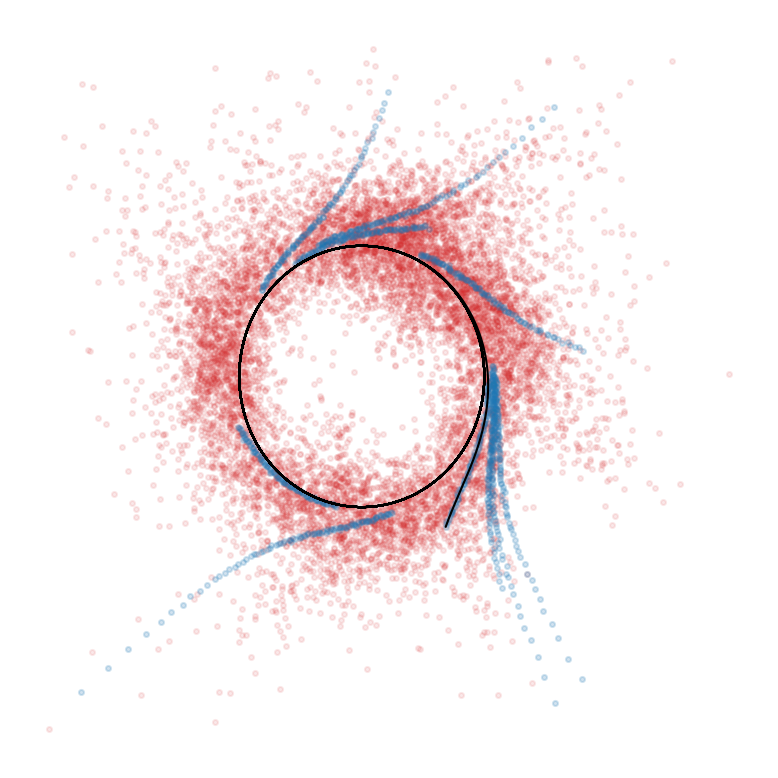

In [2]:
from mfsindy.cases.hopf_plots import plot_multifidelity_trajectories
X_ref, _, _ = generate_hopf_dataset(
    n_traj=1,
    T=100.0,
    dt=cfg.dt,
    noise_level=0.0,
    seed=cfg.seed_base,
)

X_hf_noisy, t_train, _ = generate_hopf_dataset(
    n_traj=cfg.n_hf,
    T=1,
    dt=cfg.dt,
    noise_level=cfg.noise_hf_rel*np.std(X_ref),
    seed=cfg.seed_base,
)

X_lf_noisy, _, _ = generate_hopf_dataset(
    n_traj=cfg.n_lf,
    T=1,
    dt=cfg.dt,
    noise_level=cfg.noise_lf_rel*np.std(X_ref),
    seed=cfg.seed_base + 100,
)

plot_multifidelity_trajectories(X_hf_noisy, X_lf_noisy, X_ref)


### Run

In [3]:
# (
#     _,
#     _,
#     _,
#     state_std,
#     noise_hf_abs,
#     noise_lf_abs,
# ) = run_hopf_multi_trajectory_gls_experiment(cfg)

errors_path = Path(cfg.results_dir) / cfg.results_filename
df_errors = pd.read_csv(errors_path)

def metric_values(metric: str) -> dict[str, np.ndarray]:
    return {
        m: df_errors[(df_errors["model"] == m) & (df_errors["metric"] == metric)]["value"].to_numpy()
        for m in MODELS
    }

def summarise(errors: dict[str, np.ndarray]) -> pd.DataFrame:
    rows = []
    for model, values in errors.items():
        arr = np.asarray(values, dtype=float)
        if arr.size == 0:
            continue
        rows.append(
            {
                "model": model,
                "median": float(np.median(arr)),
                "q25": float(np.percentile(arr, 25.0)),
                "q75": float(np.percentile(arr, 75.0)),
            }
        )
    return pd.DataFrame(rows).set_index("model")

mae_errors = metric_values("MAE")
l0_errors = metric_values("L0")
mae_summary = summarise(mae_errors)
l0_summary = summarise(l0_errors)

print("Mean Absolute Error")
print(mae_summary)
print("Support Fraction Error")
print(l0_summary)


Mean Absolute Error
         median       q25       q75
model                              
HF     0.391362  0.365829  0.392167
LF     0.280524  0.266157  0.294595
MF     0.241858  0.234563  0.275241
MF_w   0.005939  0.005525  0.006498
Support Fraction Error
       median    q25    q75
model                      
HF      0.875  0.750  0.875
LF      0.500  0.375  0.625
MF      0.375  0.375  0.500
MF_w    0.000  0.000  0.000


### Error summaries
Bubble histograms summarise the MAE and $L_0$ distributions across methods.

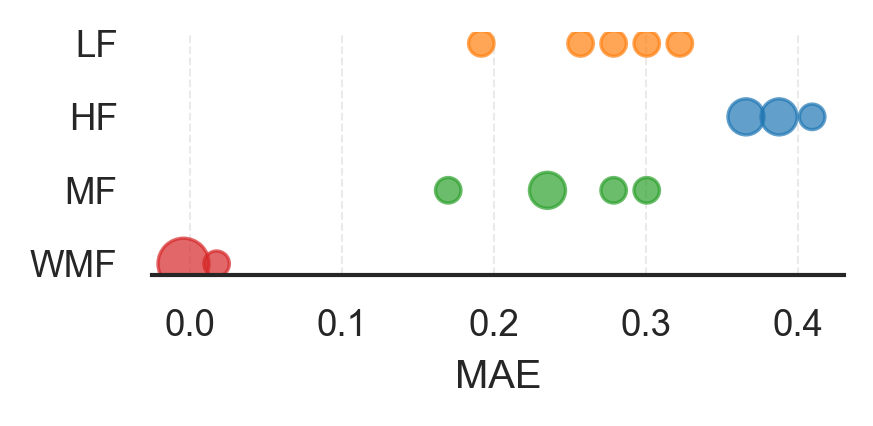

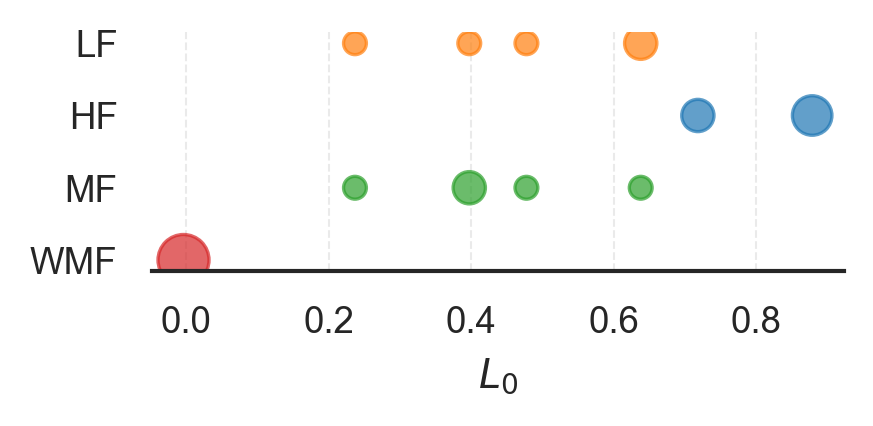

In [4]:
method_colors = {m: COLORS_MODELS.get(m, "tab:gray") for m in MODELS}
labels = ["WMF", "MF", "HF", "LF"]

bubble_hist(
    errors_dict=mae_errors,
    xlabel="MAE",
    n_bins=20,
    models_order=PLOT_ORDER,
    colors=method_colors,
    labels=labels,
)

bubble_hist(
    errors_dict=l0_errors,
    xlabel=r"$L_0$",
    n_bins=12,
    models_order=PLOT_ORDER,
    colors=method_colors,
    labels=labels,
)

